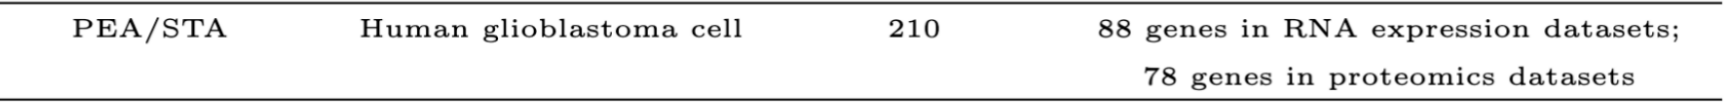

In [2]:
import numpy as np
import pandas as pd
import time
from scipy.sparse import csr_matrix
import seaborn as sns
import hypernetx as hnx
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 999)

In [1]:
from pathlib import Path

savedir = Path('./hypergraph/PEA_STA')
savedir.mkdir(parents=True, exist_ok=True)


In [3]:
expression_df = pd.read_csv('./data/PEA_STA/expression_data.csv')
expression_df.head()

,Cells,AKT1,APC,APP,AURKB,AXIN1,AXIN2,BAX,BCL2,BCL2L1,...,THY1,TNFRSF10B,TNFRSF1A,TP53,TRADD,TUBB3,TWSG1,VEGFA,VIM,XIAP
0,u3035_6d_contol_A02,0,NaN,NaN,NaN,NaN,1.179,0.741,0,4.785,...,NaN,NaN,NaN,NaN,0,0.460,0,NaN,8.831,0.0
1,u3035_6d_contol_A03,0,NaN,NaN,NaN,NaN,2.971,1.180,0,3.244,...,NaN,NaN,NaN,NaN,0,1.288,0,NaN,7.516,0.0
2,u3035_6d_contol_A04,0,NaN,NaN,NaN,NaN,0.000,0.000,0,1.042,...,NaN,NaN,NaN,NaN,0,0.000,0,NaN,8.880,0.0
3,u3035_6d_contol_A05,0,NaN,NaN,NaN,NaN,0.000,0.626,0,2.441,...,NaN,NaN,NaN,NaN,0,0.000,0,NaN,8.145,0.0
4,u3035_6d_contol_A06,0,NaN,NaN,NaN,NaN,0.000,2.711,0,0.000,...,NaN,NaN,NaN,NaN,0,0.000,0,NaN,8.571,0.0


In [4]:
protein_df = pd.read_csv('./data/PEA_STA/protein_data.csv')
protein_df.head()

,Cells,AKT1,APC,APP,AURKB,AXIN1,AXIN2,BAX,BCL2,BCL2L1,...,THY1,TNFRSF10B,TNFRSF1A,TP53,TRADD,TUBB3,TWSG1,VEGFA,VIM,XIAP
0,u3035_6d_contol_A02,NaN,0.299,0.091,0.498,0.0,NaN,NaN,NaN,NaN,...,0.0,0.017,0.216,2.226,NaN,NaN,NaN,0.0,0.000,0.0
1,u3035_6d_contol_A03,NaN,0.000,0.000,0.565,0.0,NaN,NaN,NaN,NaN,...,0.0,0.168,0.105,2.516,NaN,NaN,NaN,0.0,0.000,0.0
2,u3035_6d_contol_A04,NaN,0.000,0.003,0.509,0.0,NaN,NaN,NaN,NaN,...,0.0,0.522,0.046,2.414,NaN,NaN,NaN,0.0,0.450,0.0
3,u3035_6d_contol_A05,NaN,0.000,0.000,0.267,0.0,NaN,NaN,NaN,NaN,...,0.0,0.000,0.005,1.044,NaN,NaN,NaN,0.0,0.000,0.0
4,u3035_6d_contol_A06,NaN,0.000,0.129,0.801,0.0,NaN,NaN,NaN,NaN,...,0.0,0.724,0.231,2.686,NaN,NaN,NaN,0.0,0.442,0.0


In [10]:
df_omics = expression_df.set_index('Cells ').join(protein_df.set_index('Cells '), lsuffix='_expr', rsuffix='_protein')
df_omics.head()

,AKT1_expr,APC_expr,APP_expr,AURKB_expr,AXIN1_expr,AXIN2_expr,BAX_expr,BCL2_expr,BCL2L1_expr,BCL6_expr,...,THY1_protein,TNFRSF10B_protein,TNFRSF1A_protein,TP53_protein,TRADD_protein,TUBB3_protein,TWSG1_protein,VEGFA_protein,VIM_protein,XIAP_protein
Cells,,,,,,,,,,,,,,,,,,,,,
u3035_6d_contol_A02,0,NaN,NaN,NaN,NaN,1.179,0.741,0,4.785,NaN,...,0.0,0.017,0.216,2.226,NaN,NaN,NaN,0.0,0.000,0.0
u3035_6d_contol_A03,0,NaN,NaN,NaN,NaN,2.971,1.180,0,3.244,NaN,...,0.0,0.168,0.105,2.516,NaN,NaN,NaN,0.0,0.000,0.0
u3035_6d_contol_A04,0,NaN,NaN,NaN,NaN,0.000,0.000,0,1.042,NaN,...,0.0,0.522,0.046,2.414,NaN,NaN,NaN,0.0,0.450,0.0
u3035_6d_contol_A05,0,NaN,NaN,NaN,NaN,0.000,0.626,0,2.441,NaN,...,0.0,0.000,0.005,1.044,NaN,NaN,NaN,0.0,0.000,0.0
u3035_6d_contol_A06,0,NaN,NaN,NaN,NaN,0.000,2.711,0,0.000,NaN,...,0.0,0.724,0.231,2.686,NaN,NaN,NaN,0.0,0.442,0.0


In [11]:
df_omics_clean = df_omics.dropna(axis=1, how='all')
df_omics_clean.head()

,AKT1_expr,AXIN2_expr,BAX_expr,BCL2_expr,BCL2L1_expr,BMI1_expr,BMP2_expr,BMP4_expr,BMPR1A_expr,BMPR1B_expr,...,SOX9_protein,TENASCIN.C_protein,TGFB1_protein,THY1_protein,TNFRSF10B_protein,TNFRSF1A_protein,TP53_protein,VEGFA_protein,VIM_protein,XIAP_protein
Cells,,,,,,,,,,,,,,,,,,,,,
u3035_6d_contol_A02,0,1.179,0.741,0,4.785,0.0,0.0,0.702,0.000,0.062,...,0.0,2.260,0.409,0.0,0.017,0.216,2.226,0.0,0.000,0.0
u3035_6d_contol_A03,0,2.971,1.180,0,3.244,0.0,0.0,0.000,0.000,1.511,...,0.0,0.079,0.000,0.0,0.168,0.105,2.516,0.0,0.000,0.0
u3035_6d_contol_A04,0,0.000,0.000,0,1.042,0.0,0.0,0.010,0.000,1.905,...,0.0,0.889,0.000,0.0,0.522,0.046,2.414,0.0,0.450,0.0
u3035_6d_contol_A05,0,0.000,0.626,0,2.441,0.0,0.0,0.000,0.000,0.000,...,0.0,0.157,0.000,0.0,0.000,0.005,1.044,0.0,0.000,0.0
u3035_6d_contol_A06,0,0.000,2.711,0,0.000,0.0,0.0,0.000,0.079,0.000,...,0.0,2.151,0.000,0.0,0.724,0.231,2.686,0.0,0.442,0.0


In [12]:
def get_omics_id_from_gene(gene_name: str):
    if gene_name.endswith('_expr'):
        return 0
    if gene_name.endswith('_protein'):
        return 1
    raise ValueError(gene_name)


In [13]:
omics_names = ['Omics_Expr', 'Omics_Protein']
cell_names = df_omics_clean.index.values.tolist()
gene_names = list(df_omics_clean.columns)

In [15]:
num_cells = len(df_omics_clean)
num_genes = len(df_omics_clean.columns)
num_omics = 2
num_nodes = num_cells + num_genes + num_omics

num_cells, num_genes, num_nodes

(210, 166, 378)

In [16]:
# Node offsets
omics_offset = 0
gene_offset = num_omics
cell_offset = num_omics + num_genes

In [17]:
node_names = omics_names + gene_names + cell_names
node_names

['Omics_Expr',
 'Omics_Protein',
 'AKT1_expr',
 'AXIN2_expr',
 'BAX_expr',
 'BCL2_expr',
 'BCL2L1_expr',
 'BMI1_expr',
 'BMP2_expr',
 'BMP4_expr',
 'BMPR1A_expr',
 'BMPR1B_expr',
 'BMPR2_expr',
 'CASC3_expr',
 'CASP8_expr',
 'CAV1_expr',
 'CCND1_expr',
 'CDK5RAP1_expr',
 'CDKN1B_expr',
 'CDKN2A_expr',
 'CDKN2C_expr',
 'CHRD_expr',
 'CTNNB1_expr',
 'DLL1_expr',
 'DVL1_expr',
 'EGF_expr',
 'EGFR_expr',
 'EP300_expr',
 'EPHA2_expr',
 'ERBB2_expr',
 'FGF2_expr',
 'FOXM1_expr',
 'FZD4_expr',
 'GALC_expr',
 'GDNF_expr',
 'GFAP_expr',
 'GPX1_expr',
 'GSK3B_expr',
 'HDAC4_expr',
 'HEYL_expr',
 'ID1_expr',
 'ID2_expr',
 'ID3_expr',
 'ID4_expr',
 'IKBKG_expr',
 'JAG1_expr',
 'LEF1_expr',
 'LRP6_expr',
 'MAP1A_expr',
 'MAP3K7_expr',
 'MAPK8_expr',
 'MELK_expr',
 'MIF_expr',
 'MKI67_expr',
 'MSL1_expr',
 'MTOR_expr',
 'MYC_expr',
 'NCOR1_expr',
 'NDP_expr',
 'NEDD4_expr',
 'NES_expr',
 'NEUROD1_expr',
 'NOTCH2_expr',
 'NPM1_expr',
 'OLIG2_expr',
 'PLAU_expr',
 'PLCG1_expr',
 'PRKAA1_expr',
 'PROM1

In [18]:
node_file = savedir / 'nodes.csv'
node_file.write_text("\n".join(node_names))

6077

In [19]:
# Node offsets
omics_offset = 0
gene_offset = num_omics
cell_offset = num_omics + num_genes

In [20]:
hyper_edges = []
df = df_omics_clean

for cell_id in range(num_cells):
    for gene_id in range(num_genes):
        weight = df.iloc[cell_id, gene_id]
        if np.isnan(weight):
            continue

        omics_id = get_omics_id_from_gene(gene_names[gene_id])
        omics_node = omics_id + omics_offset
        gene_node = gene_id + gene_offset
        cell_node = cell_id + cell_offset
        edge = dict(Omics=omics_node, Gene=gene_node,
                    Cell=cell_node, Weight=weight)
        hyper_edges.append(edge)

df_edges =  pd.DataFrame.from_records(hyper_edges)

In [22]:
df_edges.head()

,Omics,Gene,Cell,Weight
0,0,2,168,0.000
1,0,3,168,1.179
2,0,4,168,0.741
3,0,5,168,0.000
4,0,6,168,4.785


In [23]:
edge_file = savedir / 'edges.csv'
df_edges.to_csv(edge_file, index=False)

In [24]:
metadata = dict(
    num_cells=num_cells, num_genes=num_genes, num_omics=num_omics,
    num_nodes=num_nodes, num_edges=len(hyper_edges),
    omics_offset=omics_offset, gene_offset=gene_offset, cell_offset=cell_offset,
)
metadata

{'num_cells': 210,
 'num_genes': 166,
 'num_omics': 2,
 'num_nodes': 378,
 'num_edges': 34860,
 'omics_offset': 0,
 'gene_offset': 2,
 'cell_offset': 168}

In [25]:
import json

metadata_file = savedir / 'metadata.json'
json.dump(metadata, metadata_file.open('w'))

In [26]:
cell_stage = np.array(pd.read_csv("data/PEA_STA/cell_stage.csv", header=None))[0]
labels = []
for each in cell_stage:
    day = each.split("_")[1]
    treat = each.split("_")[2]
    if day == "0h":
        labels.append(0)
    elif day == "6d":
        if treat == "contol":
            labels.append(1)
        elif treat == "BMP4":
            labels.append(2)

In [27]:
label_file = savedir / 'labels.csv'
label_file.write_text("\n".join(map(str, labels)))

419